# The Importance of Loss Functions

This notebook explores how the **choice of loss function** affects the fitted model.

We study two settings:

1. **Linear regression**
   - without outliers
   - with strong outliers
2. **Binary classification**
   - logistic loss
   - hinge loss

The model family is kept simple so that you can focus on the effect of the **loss function** itself.

Before running the notebook, think about these questions:

- What kinds of errors should each loss penalize the most?
- Which losses do you expect to be more sensitive to outliers?
- In classification, what do you expect to change when the loss is changed?


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression, QuantileRegressor, HuberRegressor
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Reproducibility
rng = np.random.default_rng(7)

plt.style.use("ggplot")

#### Helper functions

We define helper functions to:

- fit the same linear model using different loss functions
- generate predictions
- visualize the fitted models

You do not need to modify these functions at first. Instead, focus on using them to compare the behavior of the different losses.


In [2]:
def fit_models(X_all, y_all):
    """
    Fit linear models with four different losses:

    - MSE      : ordinary least squares
    - MAE      : least absolute deviations
    - Huber    : quadratic near zero, linear for large residuals
    - Log-Cosh : smooth robust loss

    Notes
    -----
    1. We compare the same linear model y = wx + b under different losses.
    2. For Log-Cosh we optimize the empirical risk manually because there is
       no direct scikit-learn estimator for this loss.
    """

    X_all = np.asarray(X_all).reshape(-1, 1)
    y_all = np.asarray(y_all)

    # MSE
    mse_model = LinearRegression()
    mse_model.fit(X_all, y_all)

    # MAE / LAD
    # A tiny regularization value helps numerical stability while remaining
    # essentially unregularized for teaching purposes.
    mae_model = QuantileRegressor(
        quantile=0.5,
        alpha=1e-8,
        solver="highs"
    )
    mae_model.fit(X_all, y_all)

    # Huber
    huber_model = HuberRegressor()
    huber_model.fit(X_all, y_all)

    # Log-Cosh (stable implementation)
    def logcosh_loss(theta):
        w, b = theta
        residual = y_all - (w * X_all[:, 0] + b)
        # log(cosh(r)) = log((e^r + e^{-r})/2)
        return np.mean(np.logaddexp(residual, -residual) - np.log(2.0))

    def logcosh_grad(theta):
        w, b = theta
        residual = y_all - (w * X_all[:, 0] + b)
        t = np.tanh(residual)
        grad_w = -np.mean(t * X_all[:, 0])
        grad_b = -np.mean(t)
        return np.array([grad_w, grad_b])

    # Start from the least-squares solution for faster convergence
    x0 = np.array([mse_model.coef_[0], mse_model.intercept_])

    res = minimize(
        logcosh_loss,
        x0=x0,
        jac=logcosh_grad,
        method="BFGS"
    )

    w_logcosh, b_logcosh = res.x

    return {
        "mse": mse_model,
        "mae": mae_model,
        "huber": huber_model,
        "logcosh": (w_logcosh, b_logcosh)
    }


def predict_models(models, x_plot):
    x_plot = np.asarray(x_plot).reshape(-1, 1)

    y_mse = models["mse"].predict(x_plot)
    y_mae = models["mae"].predict(x_plot)
    y_huber = models["huber"].predict(x_plot)

    w_logcosh, b_logcosh = models["logcosh"]
    y_logcosh = w_logcosh * x_plot[:, 0] + b_logcosh

    return y_mse, y_mae, y_huber, y_logcosh


def plot_results(X_all, y_all, models, title):
    X_all = np.asarray(X_all)
    y_all = np.asarray(y_all)

    x_plot = np.linspace(X_all.min(), X_all.max(), 300).reshape(-1, 1)
    y_mse, y_mae, y_huber, y_logcosh = predict_models(models, x_plot)

    plt.figure(figsize=(8, 5))
    plt.scatter(X_all, y_all, color="blue", label="data")

    plt.plot(x_plot[:, 0], y_mse, label="MSE", linewidth=3)
    plt.plot(x_plot[:, 0], y_mae, label="MAE", linewidth=3)
    plt.plot(x_plot[:, 0], y_huber, label="Huber", linewidth=3)
    plt.plot(x_plot[:, 0], y_logcosh, label="Log-Cosh", linewidth=3)

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()


## 1. Linear Regression


### 1.1. Regression without outliers

We first generate a dataset that follows a simple linear trend with small noise.

Since there are **no strong outliers**, we expect all loss functions to produce **similar fitted models**.

#### Generate dataset

In [3]:
# ---------------------------------------------------------
# Clean dataset: no outliers
# ---------------------------------------------------------
n_clean = 30

X_clean = np.linspace(0, 10, n_clean)
y_clean = 2 * X_clean + 1 + rng.normal(0, 0.8, n_clean)


#### Visualize dataset

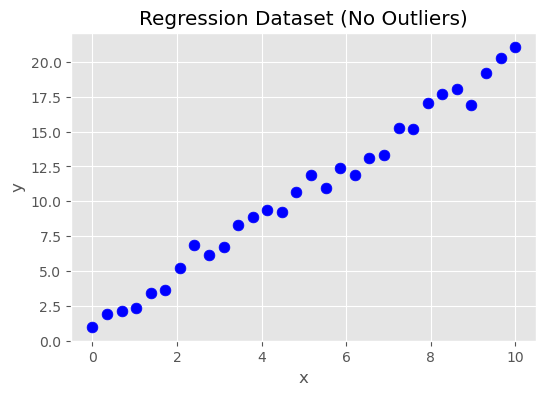

In [4]:
plt.figure(figsize=(6,4))

plt.scatter(X_clean, y_clean, color="blue", s=60)

plt.title("Regression Dataset (No Outliers)")
plt.xlabel("x")
plt.ylabel("y")

plt.grid(True)

plt.show()

#### Fit models with different losses

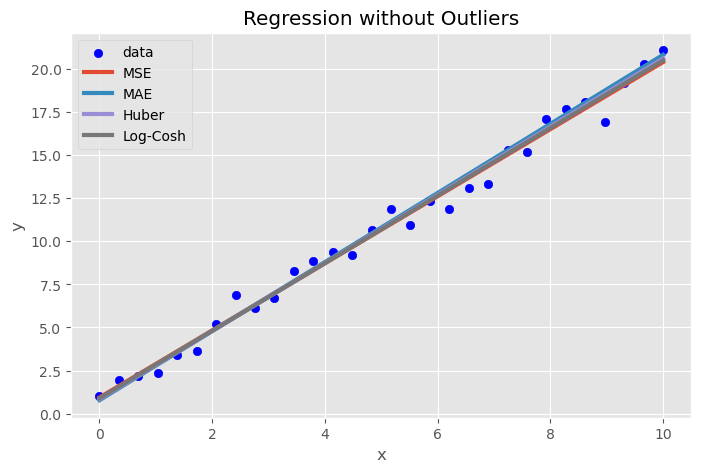

In [5]:
models_clean = fit_models(X_clean, y_clean)

plot_results(X_clean, y_clean, models_clean, "Regression without Outliers")

#### Observation

Look at the fitted lines and compare them carefully.

**Questions**
- Do the fitted models look similar or different?
- If they are similar, why might that happen in this dataset?
- What does this suggest about the importance of the loss function when the data is clean?


### 1.2. Regression with strong outliers

We now keep the same underlying linear trend, but we now add extreme observations that do not follow the linear trend.

This allows us to study how different loss functions react to **large errors**.

We expect:

- **MSE** to be strongly affected by large errors
- **MAE** to be more robust
- **Huber** to behave as a compromise
- **Log-Cosh** to remain smooth while limiting the impact of large errors

#### Generate dataset

In [6]:
# ---------------------------------------------------------
# Dataset with strong outliers
# ---------------------------------------------------------
n = 25

X = np.linspace(0, 10, n)
y = 2 * X + 1 + rng.normal(0, 0.8, n)

# Add strong outliers
X_out = np.array([1, 2, 3, 7, 8, 9])
y_out = np.array([30, 28, 35, -20, -25, -18])

X_all = np.concatenate([X, X_out])
y_all = np.concatenate([y, y_out])


#### Visualize dataset

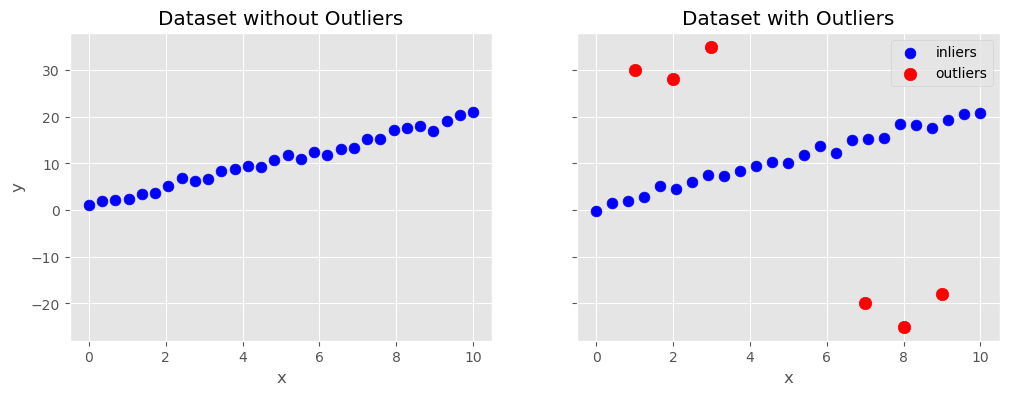

In [7]:
fig, axes = plt.subplots(1,2, figsize=(12,4), sharey=True)

# clean data
axes[0].scatter(X_clean, y_clean, color="blue", s=60)
axes[0].set_title("Dataset without Outliers")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].grid(True)

# data with outliers
axes[1].scatter(X, y, color="blue", s=60, label="inliers")
axes[1].scatter(X_out, y_out, color="red", s=80, label="outliers")
axes[1].set_title("Dataset with Outliers")
axes[1].set_xlabel("x")
axes[1].grid(True)
axes[1].legend()

plt.show()

#### Fit models with different losses

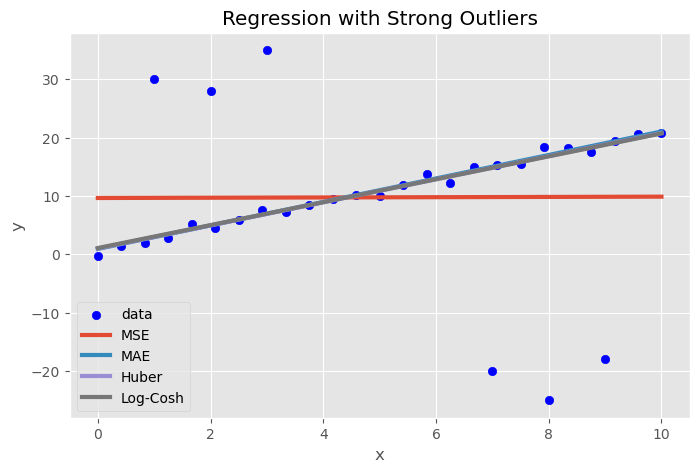

In [8]:
models_outliers = fit_models(X_all, y_all)

plot_results(X_all, y_all, models_outliers, "Regression with Strong Outliers")

#### Observation

Compare the fitted lines again, now in the presence of strong outliers.

**Questions**
- Which fitted line seems most affected by the outliers?
- Which losses appear more robust?
- How do the shapes of the different loss functions help explain this behavior?
- What kinds of errors does each loss seem to prioritize?


#### Loss and Gradient as Functions of the Residual

To understand the previous plots, we now examine each regression loss as a function of the **residual**

\begin{equation}
e = y - \hat{y}.
\end{equation}

where

- $y$ is the true value,
- $\hat{y}$ is the predicted value.

We also plot the **derivative with respect to the residual** \(e\).

As you work through this section, ask yourself:

- How fast does each loss grow as the residual increases?
- How strongly does each loss react to large errors?
- What information does the gradient add beyond the loss curve itself?


In [9]:
# ---------------------------------------------------------
# Residual range
# ---------------------------------------------------------
e = np.linspace(-10, 10, 1000)

# ---------------------------------------------------------
# Loss functions
# ---------------------------------------------------------
mse = e**2
mae = np.abs(e)

delta = 2.0
huber = np.where(np.abs(e) <= delta,
                 0.5 * e**2,
                 delta * (np.abs(e) - 0.5 * delta))

logcosh = np.log(np.cosh(e))

# ---------------------------------------------------------
# Derivatives
# ---------------------------------------------------------
mse_grad = 2 * e
mae_grad = np.sign(e)

huber_grad = np.where(np.abs(e) <= delta,
                      e,
                      delta * np.sign(e))

logcosh_grad = np.tanh(e)

#### Visual comparison of losses and gradients

- Gradient Intuition

During training, optimization algorithms update model parameters using the **gradient of the loss**.

\begin{equation}
\theta \leftarrow \theta - \eta \nabla_\theta J(\theta)
\end{equation}

The gradient determines how strongly the model reacts to prediction errors.

Large gradients produce large parameter updates, while small gradients lead to small adjustments.

Different loss functions, therefore, guide the optimization process in different ways.

A practical remark:

- for **MAE**, the derivative is not defined at \(e=0\)
- in the plot below, we use the convention $\mathrm{sign}(0)=0$.

**Questions**
- Which losses produce gradients that keep increasing with the residual?
- Which losses limit the effect of very large residuals?
- How might this influence robustness during training?


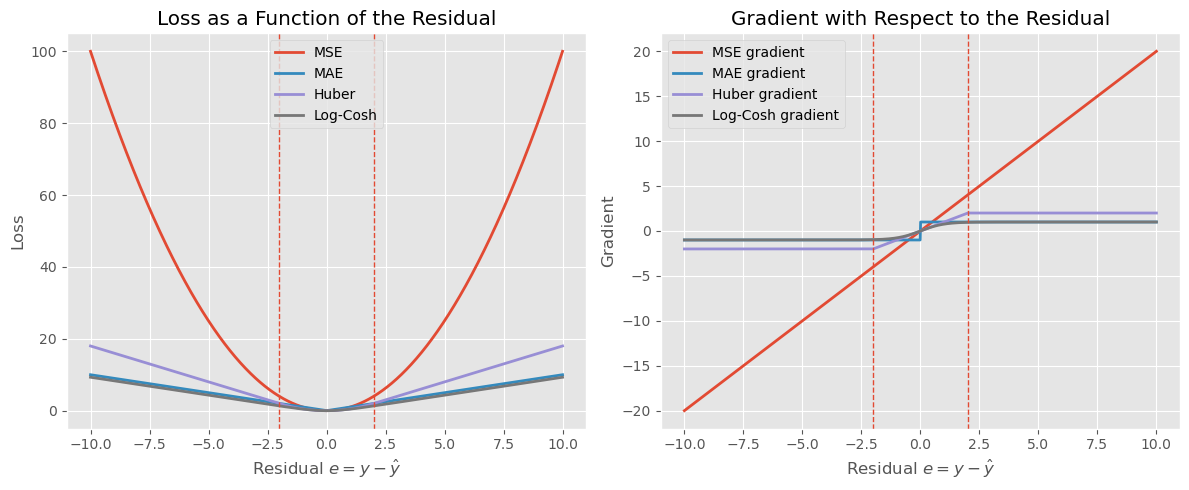

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Left: losses ----
axes[0].plot(e, mse, label="MSE", linewidth=2)
axes[0].plot(e, mae, label="MAE", linewidth=2)
axes[0].plot(e, huber, label="Huber", linewidth=2)
axes[0].plot(e, logcosh, label="Log-Cosh", linewidth=2)

axes[0].axvline(delta, linestyle="--", linewidth=1)
axes[0].axvline(-delta, linestyle="--", linewidth=1)

axes[0].set_title("Loss as a Function of the Residual")
axes[0].set_xlabel("Residual $e = y - \\hat{y}$")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# ---- Right: gradients ----
axes[1].plot(e, mse_grad, label="MSE gradient", linewidth=2)
axes[1].plot(e, mae_grad, label="MAE gradient", linewidth=2)
axes[1].plot(e, huber_grad, label="Huber gradient", linewidth=2)
axes[1].plot(e, logcosh_grad, label="Log-Cosh gradient", linewidth=2)

axes[1].axvline(delta, linestyle="--", linewidth=1)
axes[1].axvline(-delta, linestyle="--", linewidth=1)

axes[1].set_title("Gradient with Respect to the Residual")
axes[1].set_xlabel("Residual $e = y - \\hat{y}$")
axes[1].set_ylabel("Gradient")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### Interpretation

Use the loss and gradient plots to justify what you observed in the regression experiments.

**Questions**
- Which loss grows fastest for large residuals?
- Which loss gives approximately constant gradient magnitude away from zero?
- Which losses combine sensitivity near zero with robustness for large residuals?
- Which loss seems smooth everywhere?
- How do these properties explain the fitted lines you saw before?

Write a short summary in your own words.


### From Regression Losses to Classification Losses

In regression problems, loss functions are applied to the **residual**

\begin{equation}
e = y - \hat{y}.
\end{equation}

In classification problems, losses are often expressed in terms of the **margin**

\begin{equation}
m = y f(x).
\end{equation}

Before continuing, think about the analogy:

- What does the residual measure in regression?
- What might the margin measure in classification?
- Why is it useful to compare losses through these quantities?


## 2. Binary Classification

In this section we compare two standard linear classifiers:

- **Logistic Regression**, trained with the **logistic loss**
- **Linear SVM**, trained with the **hinge loss**

We use three complementary views:

1. a clean binary dataset and the resulting decision boundaries,
2. the loss as a function of the **margin**,
3. the difference between **probabilities** and **decision scores**.

As you work through this section, try to answer:

- If two classifiers produce similar boundaries, are they really learning in the same way?
- What does each loss encourage the classifier to do?
- How should we interpret the outputs of each model?


In [11]:
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

#### Helper functions

We define helper functions to:

- fit Logistic Regression and Linear SVM
- plot the dataset
- plot decision boundaries
- compare probabilities and decision scores

Use these helper functions to compare the models, but make sure you interpret what you see before moving on.


In [12]:
def fit_classification_models(X, y):
    """
    Fit two linear classifiers on standardized features:

    - Logistic Regression  -> logistic loss
    - Linear SVM           -> hinge loss

    Standardization is included so that the comparison is not distorted by
    feature scale.
    """
    log_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(random_state=0)
    )
    log_model.fit(X, y)

    svm_model = make_pipeline(
        StandardScaler(),
        LinearSVC(random_state=0, dual="auto")
    )
    svm_model.fit(X, y)

    return {
        "logistic": log_model,
        "svm": svm_model
    }


def plot_dataset(X, y, title):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, s=60)
    plt.title(title)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.grid(True)
    plt.show()


def plot_decision_boundaries(X, y, models, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z_log = models["logistic"].predict(grid).reshape(xx.shape)
    Z_svm = models["svm"].predict(grid).reshape(xx.shape)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

    axes[0].contourf(xx, yy, Z_log, alpha=0.2)
    axes[0].scatter(X[:, 0], X[:, 1], c=y, s=60)
    axes[0].set_title("Logistic Regression (logistic loss)")
    axes[0].set_xlabel("$x_1$")
    axes[0].set_ylabel("$x_2$")
    axes[0].grid(True)

    axes[1].contourf(xx, yy, Z_svm, alpha=0.2)
    axes[1].scatter(X[:, 0], X[:, 1], c=y, s=60)
    axes[1].set_title("Linear SVM (hinge loss)")
    axes[1].set_xlabel("$x_1$")
    axes[1].set_ylabel("$x_2$")
    axes[1].grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_probability_and_score(X, y, models, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    prob = models["logistic"].predict_proba(grid)[:, 1].reshape(xx.shape)
    score = models["svm"].decision_function(grid).reshape(xx.shape)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

    c1 = axes[0].contourf(xx, yy, prob, levels=30)
    axes[0].scatter(X[:, 0], X[:, 1], c=y, edgecolor="black", s=50)
    axes[0].set_title("Logistic Regression: probability")
    axes[0].set_xlabel("$x_1$")
    axes[0].set_ylabel("$x_2$")
    axes[0].grid(True)
    fig.colorbar(c1, ax=axes[0])

    c2 = axes[1].contourf(xx, yy, score, levels=30)
    axes[1].scatter(X[:, 0], X[:, 1], c=y, edgecolor="black", s=50)
    axes[1].set_title("Linear SVM: decision score")
    axes[1].set_xlabel("$x_1$")
    axes[1].set_ylabel("$x_2$")
    axes[1].grid(True)
    fig.colorbar(c2, ax=axes[1])

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


### Generate dataset

In [13]:
X_clean, y_clean = make_blobs(
    n_samples=200,
    centers=2,
    cluster_std=1.2,
    random_state=4
)

### Visualize dataset

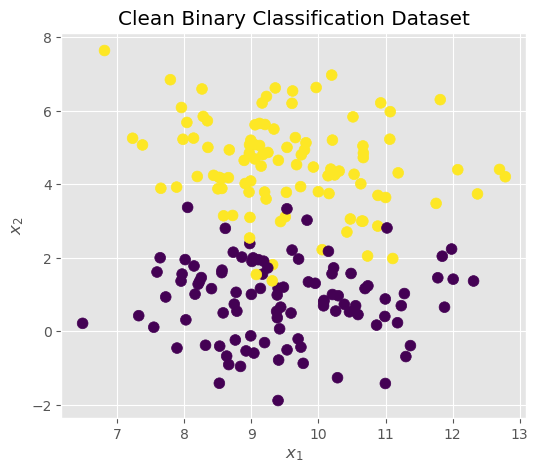

In [14]:
plot_dataset(X_clean, y_clean, "Clean Binary Classification Dataset")

### Fit models with different losses (Logistic Regression and SVM)

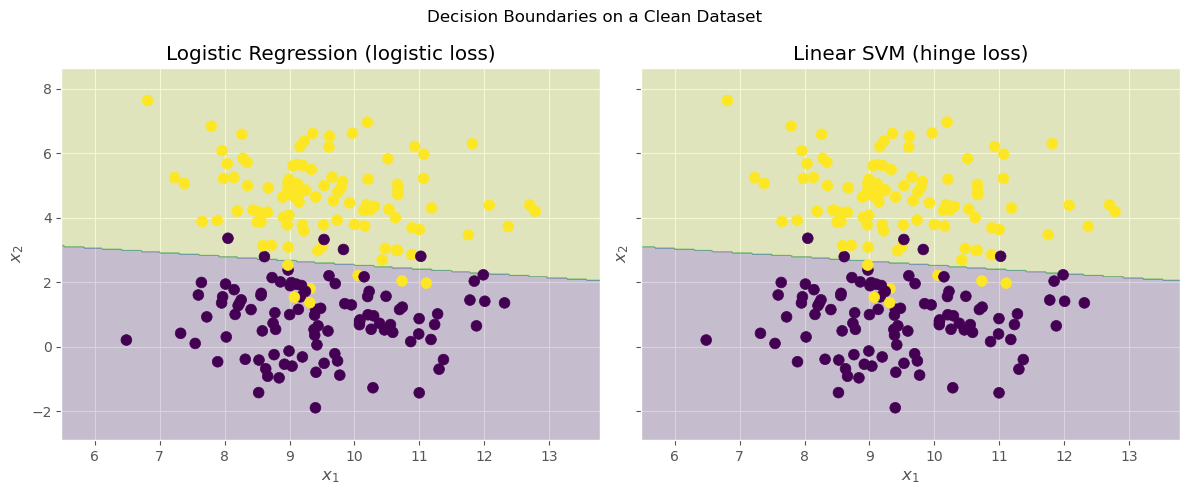

In [15]:
models_clean = fit_classification_models(X_clean, y_clean)

plot_decision_boundaries(
    X_clean,
    y_clean,
    models_clean,
    "Decision Boundaries on a Clean Dataset"
)

### Observation

Inspect the two decision boundaries.

**Questions**
- Do the classifiers produce very different boundaries or fairly similar ones?
- Is a boundary plot alone enough to understand the difference between the two losses?
- What additional information would you need in order to compare them more deeply?


### Binary Classification Losses as Functions of the Margin

To understand the real difference between **Binary Cross-Entropy** and **Hinge Loss**, it is useful to analyze them as functions of the **margin**

$$
m = y\,f(x),
$$

where

- $y \in \{-1,+1\}$ is the **true class label**,  
- $f(x)$ is the **classification score** produced by the model.

The margin measures how confident the classifier is in its prediction.

**Interpretation of the margin**

The margin has the following interpretation:

- $m > 0$ : correct classification  
- $m < 0$ : incorrect classification  
- larger positive $m$ indicates a more confident correct classification  

**Note on label encoding**

For margin-based losses (such as **hinge loss** used in Support Vector Machines), it is convenient to use labels

$$
y \in \{-1,+1\}.
$$

In many machine learning libraries (such as `scikit-learn`), labels are instead encoded as

$$
y \in \{0,1\}.
$$

Both encodings represent the same classes, but the $\{-1,+1\}$ convention simplifies the mathematical expression of margin-based losses.

Before looking at the plot, predict:

- Which loss will keep penalizing even when the margin is already positive and large?
- Which loss will stop penalizing after a threshold?
- What kind of classifier behavior should each loss encourage?


In [16]:
# ---------------------------------------------------------
# Margin range
# ---------------------------------------------------------
m = np.linspace(-5, 5, 1000)

# ---------------------------------------------------------
# Losses as functions of the margin
# ---------------------------------------------------------
logistic_loss = np.log1p(np.exp(-m))
hinge = np.maximum(0, 1 - m)

# ---------------------------------------------------------
# Derivatives with respect to the margin
# ---------------------------------------------------------
logistic_grad = -1 / (1 + np.exp(m))
hinge_grad = np.where(m < 1, -1, 0)


### Visual comparison of losses and gradients

The following plot shows how different loss functions behave as a function of the margin.

Before interpreting it, try to identify:

- where each loss penalizes wrong predictions most strongly,
- whether each loss still penalizes correctly classified points,
- how the gradient changes as the margin increases.


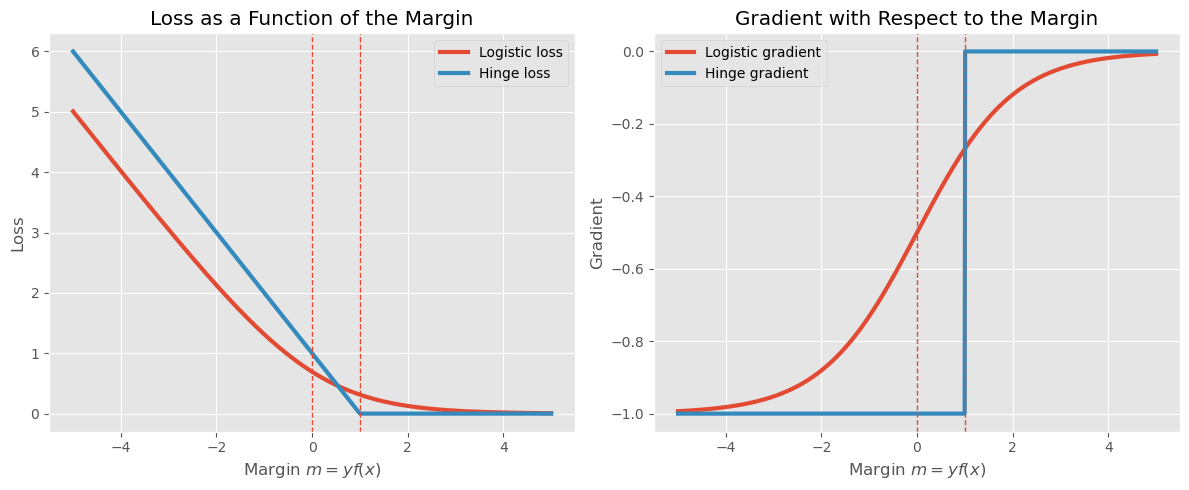

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Left: losses ----
axes[0].plot(m, logistic_loss, label="Logistic loss", linewidth=3)
axes[0].plot(m, hinge, label="Hinge loss", linewidth=3)

axes[0].axvline(0, linestyle="--", linewidth=1)
axes[0].axvline(1, linestyle="--", linewidth=1)

axes[0].set_title("Loss as a Function of the Margin")
axes[0].set_xlabel("Margin $m = y f(x)$")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# ---- Right: gradients ----
axes[1].plot(m, logistic_grad, label="Logistic gradient", linewidth=3)
axes[1].plot(m, hinge_grad, label="Hinge gradient", linewidth=3)

axes[1].axvline(0, linestyle="--", linewidth=1)
axes[1].axvline(1, linestyle="--", linewidth=1)

axes[1].set_title("Gradient with Respect to the Margin")
axes[1].set_xlabel("Margin $m = y f(x)$")
axes[1].set_ylabel("Gradient")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


#### Interpretation

Study the loss and gradient curves carefully.

**Questions**
- Which loss is smooth?
- Which loss becomes zero after the margin reaches a threshold?
- Which loss continues to penalize correctly classified points?
- How does each loss encourage a different notion of confidence?
- How can two models have similar boundaries but different learning objectives?

Summarize the main conceptual difference in one or two sentences.


### Probability distribution versus decision score

Another important difference lies in the interpretation of the output.

- Logistic Regression produces an output through the sigmoid link.
- Linear SVM produces a real-valued decision score.

We visualize both quantities on the same dataset.

**Questions**
- Which output can be interpreted as a probability?
- Which output is better viewed as a score relative to the separating boundary?
- How might this affect how you use the model in practice?


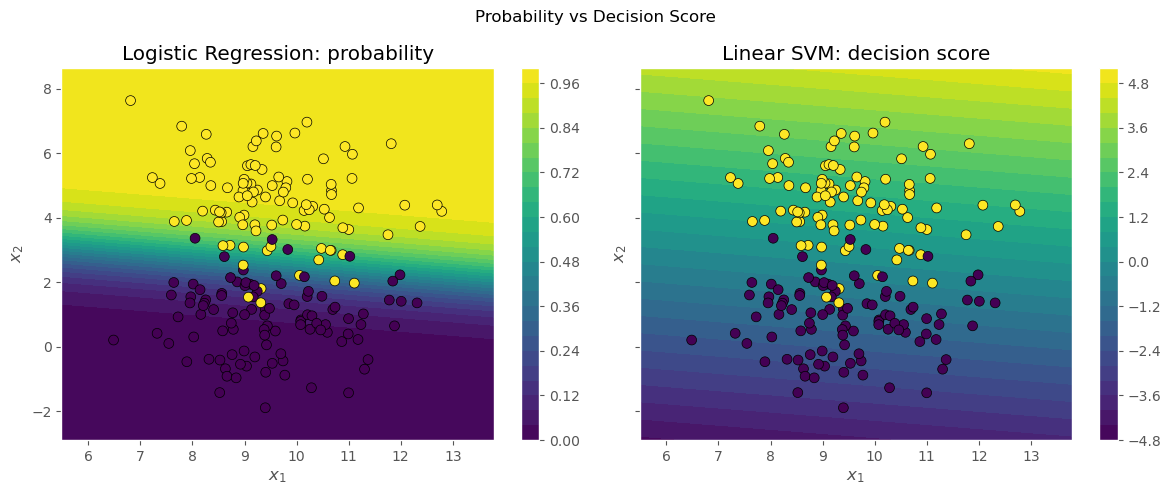

In [18]:
plot_probability_and_score(
    X_clean,
    y_clean,
    models_clean,
    "Probability vs Decision Score"
)

#### Interpretation

Use the plots to compare how the two models encode confidence.

**Questions**
- What range of values does Logistic Regression return?
- What does a value close to 0.5 mean?
- What does the sign of the SVM score tell you?
- What does the magnitude of the SVM score tell you?
- How does the loss function affect the meaning of the model output?


## Takeaways

Complete the following summary in your own words.

1. In regression, what changes when outliers are introduced?

2. In classification, why do similar decision boundaries not necessarily mean that the models are learning the same thing?

3. How does the loss function influence both the **robustness of the model** and the **interpretation of its predictions**?

4. Why can choosing the loss function be as important as choosing the model itself?


## EXTRA: Gradients and curvature

To understand why some losses are more robust than others, it is useful to compare not only their values, but also their **gradients** and **second derivatives**.

- The **gradient** shows how strongly the loss reacts to an error.
- The **second derivative** shows the local curvature of the objective.

As you explore this section, think about:

- Which losses have constant curvature?
- Which losses lose curvature in the tails?
- How could curvature affect optimization and sensitivity to outliers?


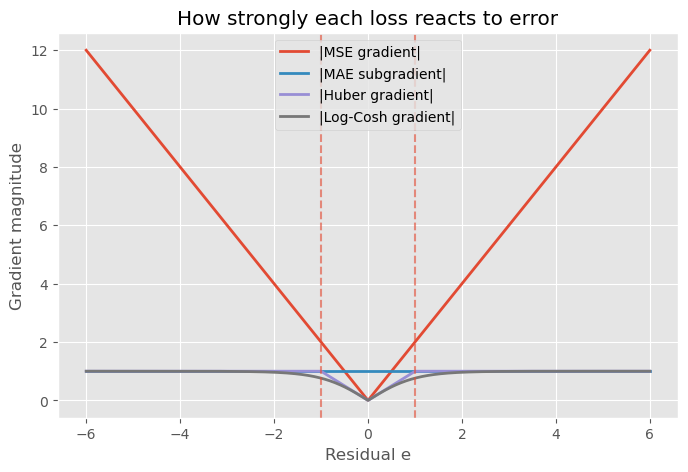

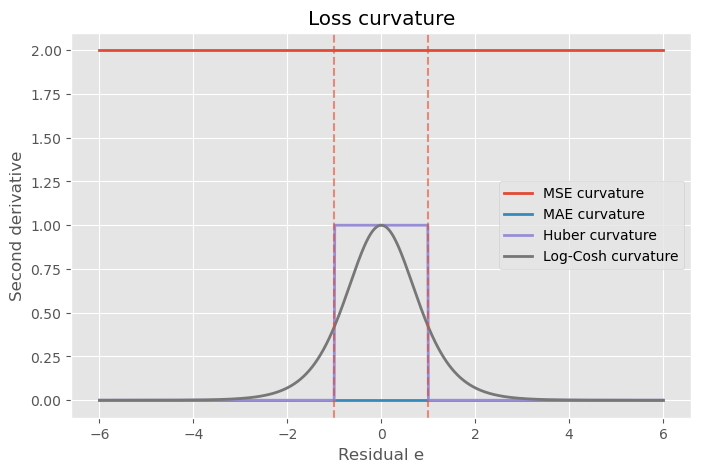

In [19]:
# Compare gradient magnitude and curvature of common regression losses
import numpy as np
import matplotlib.pyplot as plt

e = np.linspace(-6, 6, 1000)
delta = 1.0

# MSE
mse = e**2
mse_grad = 2 * e
mse_hess = 2 * np.ones_like(e)

# MAE
mae = np.abs(e)
mae_grad = np.sign(e)
mae_grad[np.abs(e) < 1e-12] = 0
mae_hess = np.zeros_like(e)   # formal visualization; undefined at 0

# Huber
huber = np.where(np.abs(e) <= delta,
                 0.5 * e**2,
                 delta * (np.abs(e) - 0.5 * delta))
huber_grad = np.where(np.abs(e) <= delta,
                      e,
                      delta * np.sign(e))
huber_hess = np.where(np.abs(e) <= delta, 1.0, 0.0)

# Log-Cosh
logcosh = np.log(np.cosh(e))
logcosh_grad = np.tanh(e)
logcosh_hess = 1 / np.cosh(e)**2

# ---- Plot 1: gradient magnitude ----
plt.figure(figsize=(8, 5))
plt.plot(e, np.abs(mse_grad), label="|MSE gradient|", linewidth=2)
plt.plot(e, np.abs(mae_grad), label="|MAE subgradient|", linewidth=2)
plt.plot(e, np.abs(huber_grad), label="|Huber gradient|", linewidth=2)
plt.plot(e, np.abs(logcosh_grad), label="|Log-Cosh gradient|", linewidth=2)
plt.axvline(delta, linestyle="--", alpha=0.6)
plt.axvline(-delta, linestyle="--", alpha=0.6)
plt.xlabel("Residual e")
plt.ylabel("Gradient magnitude")
plt.title("How strongly each loss reacts to error")
plt.legend()
plt.grid(True)
plt.show()

# ---- Plot 2: curvature ----
plt.figure(figsize=(8, 5))
plt.plot(e, mse_hess, label="MSE curvature", linewidth=2)
plt.plot(e, mae_hess, label="MAE curvature", linewidth=2)
plt.plot(e, huber_hess, label="Huber curvature", linewidth=2)
plt.plot(e, logcosh_hess, label="Log-Cosh curvature", linewidth=2)
plt.axvline(delta, linestyle="--", alpha=0.6)
plt.axvline(-delta, linestyle="--", alpha=0.6)
plt.xlabel("Residual e")
plt.ylabel("Second derivative")
plt.title("Loss curvature")
plt.legend()
plt.grid(True)
plt.show()